# Overfitting single intervals

## imports

In [1]:
import os
import pandas as pd
import torch
from safetensors.torch import load_file
import yaml
import seaborn as sns
import matplotlib.pyplot as plt

from figutils import (
    cm,
    set_figure_style, 
)

set_figure_style()

PAL_MODALITIES = {
    "rna_seq": "#717EC3",
    "splice_site": "#AE8799",
    "splice_usage": "#C95D63",
    "splice_junctions": "#EE8434"
}

MAP_MODALITIES = {
    "rna_seq_1bp_profile_pearson_r_mean":"rna_seq",
    "splice_site_auprc_macro":"splice_site",
    "splice_site_auprc_weighted":"splice_site",
    "splice_usage_pearson_r":"splice_usage",
    "splice_junctions_pearson_r":"splice_junctions"
}

OUTPUT_DIR = os.path.join("pdfs","overfitting_single")
os.makedirs(OUTPUT_DIR, exist_ok=True)

## data

In [2]:
# paths

ROOT = ".."
OUTPUT_DIR = os.path.join(ROOT,"results/bsc/finetuning/alphagenome_pytorch/overfitting/single")
with open(os.path.join(ROOT,"config","config.yaml"), "r") as stream:
    config = yaml.safe_load(stream)

logs_file = os.path.join(OUTPUT_DIR, "summary", "epoch_logs.parquet")

weights_file = os.path.join(ROOT,config["alphagenome_pytorch"]["paths"]["weights"])

In [3]:
# loads

logs = pd.read_parquet(logs_file)
weights = load_file(weights_file)

## figures

In [4]:
logs = logs.loc[~logs.duplicated(subset=["run_name", "epoch"], keep="last")].copy()
logs.value_counts(["density","run_name"])

density  run_name                                                                     
medium   original__all__bfloat16                                                          500
         debug_splice_sites__randinit_noseg_gtf__all__bfloat16                            500
         debug_splice_sites__randinit_seg_gtf__all__bfloat16                              500
         debug_splice_sites__randinit_seg_nogtf__all__bfloat16                            500
         debug_splice_sites__pretrinit_seg_nogtf__all__bfloat16                           500
         debug_splice_sites__pretrinit_seg_gtf__all__bfloat16                             500
         debug_splice_sites__pretrinit_noseg_gtf__all__bfloat16                           500
         debug_splice_junctions__origrope__origloss__annotated__randinit__bfloat16        500
         debug_splice_junctions__origrope__origloss__annotated__pretrinit__bfloat16       500
         debug_splice_junctions__origrope__origloss__predicted__ran

### splice site and junction heads struggle to overfit a single interval

In [5]:
X = logs.query("run_name.str.contains('original__all')")

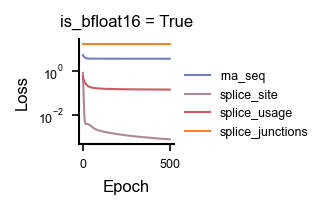

In [6]:
x = (
    X[
        ["epoch","run_name","val_loss_rna_seq_loss","val_loss_splice_site_loss","val_loss_splice_usage_loss","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)
x["is_bfloat16"] = x["run_name"].str.contains("bfloat16")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="modality", palette=PAL_MODALITIES,
    col="is_bfloat16",
    linewidth=1,
    facet_kws=dict(sharey=True),
    height=3.5*cm, aspect=1
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.legend.set_title("")

plt.show()

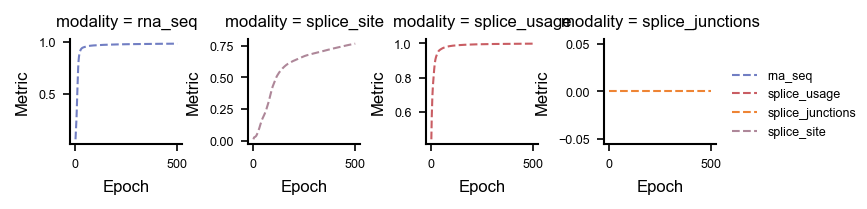

In [7]:
x = pd.concat([
    (
        X[
            ["epoch","run_name","rna_seq_1bp_profile_pearson_r_mean","splice_usage_pearson_r","splice_junctions_pearson_r"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="correlation")
    ),
    (
        X[
            ["epoch","run_name","splice_site_auprc_macro"]#,"splice_site_auprc_acceptor_pos","splice_site_auprc_acceptor_pos","splice_site_auprc_donor_neg","splice_site_auprc_acceptor_neg"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["modality"] = x["modality"].map({
    "rna_seq_1bp_profile_pearson_r_mean":"rna_seq",
    "splice_site_auprc_macro":"splice_site",
    "splice_usage_pearson_r":"splice_usage",
    "splice_junctions_pearson_r":"splice_junctions",
    "splice_junctions_pearson_r_psi5":"splice_junctions",
    "splice_junctions_pearson_r_psi3":"splice_junctions"
})
x["is_bfloat16"] = x["run_name"].str.contains("bfloat16")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="modality", palette=PAL_MODALITIES,
    col="modality", col_order=list(PAL_MODALITIES.keys()),
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=False),
    height=3.5*cm, aspect=0.9
)

g.set(
    xlabel="Epoch",
    ylabel="Metric"
)
g.legend.set_title("")

plt.show()

### splice site head is not influenced by segmentation or lack of annotated splice sites

In [11]:
X = logs.query("run_name.str.contains('debug_splice_site')")

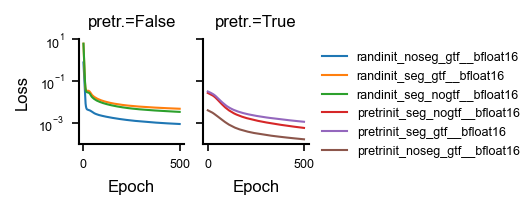

In [15]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_site_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)
x["is_pretrained"] = x["run_name"].str.contains("pretrinit")
x["run_name"] = x["run_name"].str.replace("debug_splice_sites__","").str.replace("__all","")
x["is_bfloat16"] = x["run_name"].str.contains("bfloat16")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="loss",
    hue="run_name",
    col="is_pretrained",
    linewidth=1,
    facet_kws=dict(sharey=True),
    height=3.5*cm, aspect=0.8
)

g.set(
    xlabel="Epoch",
    ylabel="Loss",
    yscale="log",
)
g.set_titles("pretr.={col_name}")
g.legend.set_title("")

plt.show()

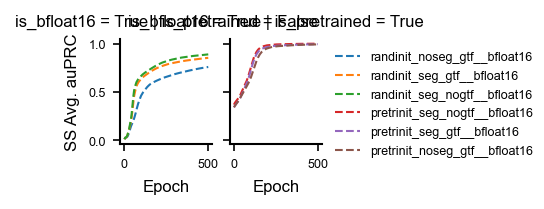

In [17]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_site_auprc_macro"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["is_pretrained"] = x["run_name"].str.contains("pretrinit")
x["run_name"] = x["run_name"].str.replace("debug_splice_sites__","").str.replace("__all","")
x["is_bfloat16"] = x["run_name"].str.contains("bfloat16")

g = sns.relplot(
    kind="line",
    data=x,
    x="epoch",
    y="metric_value",
    hue="run_name",
    col="is_pretrained",
    row="is_bfloat16",
    linewidth=1, linestyle="dashed",
    facet_kws=dict(sharey=True),
    height=3.5*cm, aspect=0.8
)

g.set(
    xlabel="Epoch",
    ylabel="SS Avg. auPRC"
)
g.legend.set_title("")

plt.show()

### initiating rope parameters with truncated normal distribution enables learning

In [18]:
X = logs.query("run_name.str.contains('debug_splice_junctions')")

is_bfloat16


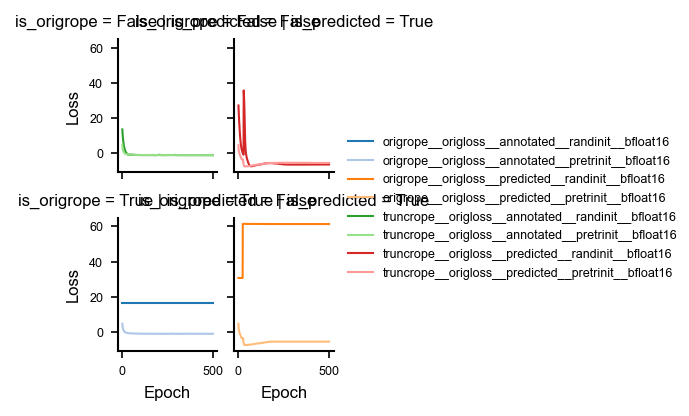

In [21]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)
x["is_pretrained"] = x["run_name"].str.contains("pretrinit")
x["is_predicted"] = x["run_name"].str.contains("predicted")
x["is_origrope"] = x["run_name"].str.contains("origrope")
x["is_bfloat16"] = x["run_name"].str.contains("bfloat16")
x["run_name"] = x["run_name"].str.replace("debug_splice_junctions__","")
x = x.query("run_name.str.contains('origloss')")

for dtype in ["is_bfloat16"]:
        
    print(dtype)
    if dtype=="is_bfloat16":
        data = x[x["is_bfloat16"]]
    else:
        data = x[~x["is_bfloat16"]]
    
    g = sns.relplot(
        kind="line",
        data=data,
        x="epoch",
        y="loss",
        hue="run_name", palette="tab20",
        col="is_predicted",
        row="is_origrope",
        linewidth=1,
        facet_kws=dict(sharey=True),
        height=3.5*cm, aspect=0.85
    )

    g.set(
        xlabel="Epoch",
        ylabel="Loss",
        yscale="linear",
    )
    g.legend.set_title("")

    plt.show()

is_bfloat16


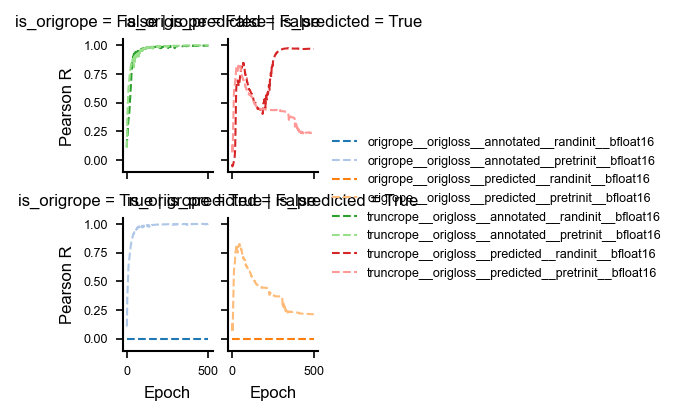

In [26]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_junctions_pearson_r_psi3"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["is_pretrained"] = x["run_name"].str.contains("pretrinit")
x["is_predicted"] = x["run_name"].str.contains("predicted")
x["is_origrope"] = x["run_name"].str.contains("origrope")
x["is_bfloat16"] = x["run_name"].str.contains("bfloat16")
x["run_name"] = x["run_name"].str.replace("debug_splice_junctions__","")
x = x.query("run_name.str.contains('origloss')")

for dtype in ["is_bfloat16"]:
        
    print(dtype)
    if dtype=="is_bfloat16":
        data = x[x["is_bfloat16"]]
    else:
        data = x[~x["is_bfloat16"]]
    
    g = sns.relplot(
        kind="line",
        data=data,
        x="epoch",
        y="metric_value",
        hue="run_name", palette="tab20",
        col="is_predicted",
        row="is_origrope",
        linewidth=1, linestyle="dashed",
        facet_kws=dict(sharey=True),
        height=3.5*cm, aspect=0.85
    )

    g.set(
        xlabel="Epoch",
        ylabel="Pearson R"
    )
    g.legend.set_title("")

    plt.show()

### consensus loss could offer marginal improvement

is_bfloat16


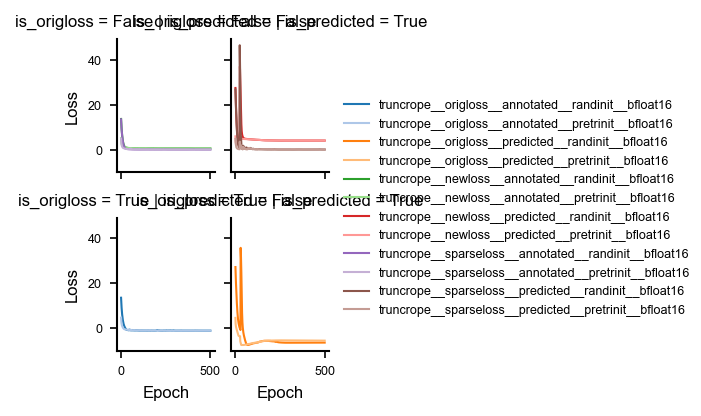

In [29]:
x = (
    X[
        ["epoch","density","run_name","val_loss_splice_junctions_loss"]
    ].drop_duplicates()
    .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="loss")
    .assign(modality=lambda d: d["modality"].str.replace("val_loss_","").str.replace("_loss",""))
)
x["is_pretrained"] = x["run_name"].str.contains("pretrinit")
x["is_predicted"] = x["run_name"].str.contains("predicted")
x["is_origloss"] = x["run_name"].str.contains("origloss")
x["is_bfloat16"] = x["run_name"].str.contains("bfloat16")
x["run_name"] = x["run_name"].str.replace("debug_splice_junctions__","")
x = x.query("run_name.str.contains('truncrope')")

for dtype in ["is_bfloat16"]:
        
    print(dtype)
    if dtype=="is_bfloat16":
        data = x[x["is_bfloat16"]]
    else:
        data = x[~x["is_bfloat16"]]
        
    g = sns.relplot(
        kind="line",
        data=data,
        x="epoch",
        y="loss",
        hue="run_name", palette="tab20",
        col="is_predicted",
        row="is_origloss",
        linewidth=1,
        facet_kws=dict(sharey=True),
        height=3.5*cm, aspect=0.85
    )

    g.set(
        xlabel="Epoch",
        ylabel="Loss",
        yscale="linear",
    )
    g.legend.set_title("")

    plt.show()

is_bfloat16


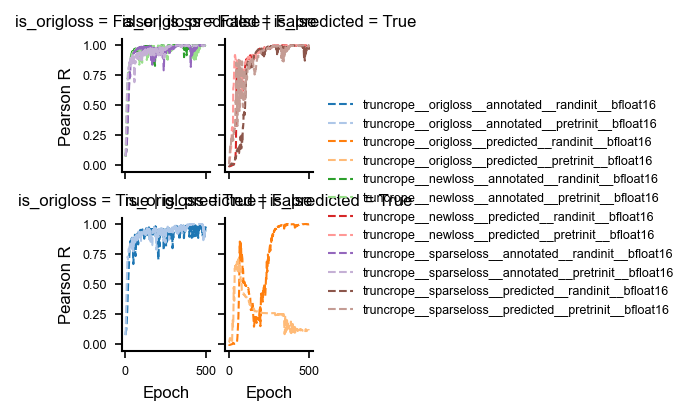

In [31]:
x = pd.concat([
    (
        X[
            ["epoch","density","run_name","splice_junctions_pearson_r"]
        ].drop_duplicates()
        .melt(id_vars=["epoch","density","run_name"], var_name="modality", value_name="metric_value")
        .assign(metric_name="auprc")
    )
])
x["is_pretrained"] = x["run_name"].str.contains("pretrinit")
x["is_predicted"] = x["run_name"].str.contains("predicted")
x["is_origloss"] = x["run_name"].str.contains("origloss")
x["is_bfloat16"] = x["run_name"].str.contains("bfloat16")
x["run_name"] = x["run_name"].str.replace("debug_splice_junctions__","")
x = x.query("run_name.str.contains('truncrope')")

for dtype in ["is_bfloat16"]:
        
    print(dtype)
    if dtype=="is_bfloat16":
        data = x[x["is_bfloat16"]]
    else:
        data = x[~x["is_bfloat16"]]
        
    g = sns.relplot(
        kind="line",
        data=data,
        x="epoch",
        y="metric_value",
        hue="run_name", palette="tab20",
        col="is_predicted",
        row="is_origloss",
        linewidth=1, linestyle="dashed",
        facet_kws=dict(sharey=True),
        height=3.5*cm, aspect=0.85
    )

    g.set(
        xlabel="Epoch",
        ylabel="Pearson R"
    )
    g.legend.set_title("")

    plt.show()

### distributions of RoPE trained weights

In [32]:
weights_oi = [w for w in weights.keys() if "rope" in w]

for w in weights_oi:
    
    print(w)
    print(weights[w].shape) # num_organisms, 2 (scale and offset), num_tissues, hidden_dim

splice_sites_junction_head.rope_params.neg_acceptor
torch.Size([2, 2, 367, 768])
splice_sites_junction_head.rope_params.neg_donor
torch.Size([2, 2, 367, 768])
splice_sites_junction_head.rope_params.pos_acceptor
torch.Size([2, 2, 367, 768])
splice_sites_junction_head.rope_params.pos_donor
torch.Size([2, 2, 367, 768])


In [ ]:
idx_oi = 139
shape_weights = weights[w][:,:,[idx_oi],:].shape
std = 0.1

X = pd.concat([  
    pd.concat([
        pd.DataFrame({"weight_key": w, "weight_value": weights[w][:,:,[idx_oi],:].numpy().ravel()})
        for w in weights_oi
    ]),
    pd.concat([
        pd.DataFrame({
            "weight_key": "zero_init", 
            "weight_value": torch.zeros(shape_weights).numpy().ravel()
        }),
        pd.DataFrame({
            "weight_key": "truncnormal_init",
            "weight_value": torch.nn.init.trunc_normal_(
                torch.empty(shape_weights), mean=0.0, std=std, a=-2 * std, b=2 * std,
            ).numpy().ravel()
        })
    ])
])
X["is_pretrained"] = X["weight_key"].str.contains('splice_sites_junction_head')
X["weight_key"] = X["weight_key"].str.replace("splice_sites_junction_head.rope_params.","")

g = sns.displot(
    kind="hist",
    data=X,
    x="weight_value",
    col="weight_key",
    hue="is_pretrained", palette="Dark2",
    bins=50,
    height=3.25*cm, aspect=0.7
)
print(len(X.query("weight_key=='truncnormal_init'")))

plt.show()